<a href="https://colab.research.google.com/github/talatak/COMP433-MABe-BehaviorRecognition/blob/colab-setup/00_MABe_colab_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!git clone https://github.com/talatak/COMP433-MABe-BehaviorRecognition.git
%cd COMP433-MABe-BehaviorRecognition
!git config user.name "Tala Tak"
!git config user.email "talatakwo@gmail.com"
!git checkout -b colab-setup
!mkdir -p notebooks data


Cloning into 'COMP433-MABe-BehaviorRecognition'...
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 5 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (5/5), done.
/content/COMP433-MABe-BehaviorRecognition
Switched to a new branch 'colab-setup'


In [6]:
import sys, torch, platform, os
print("Python:", sys.version.split()[0])
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("CWD:", os.getcwd())
!ls -la


Python: 3.12.12
CUDA available: True
GPU: Tesla T4
CWD: /content/COMP433-MABe-BehaviorRecognition
total 36
drwxr-xr-x 5 root root 4096 Oct 30 22:08 .
drwxr-xr-x 1 root root 4096 Oct 30 22:08 ..
drwxr-xr-x 2 root root 4096 Oct 30 22:08 data
drwxr-xr-x 8 root root 4096 Oct 30 22:08 .git
-rw-r--r-- 1 root root 4688 Oct 30 22:08 .gitignore
-rw-r--r-- 1 root root 1064 Oct 30 22:08 LICENSE
drwxr-xr-x 2 root root 4096 Oct 30 22:08 notebooks
-rw-r--r-- 1 root root  135 Oct 30 22:08 README.md


In [7]:
# Step 2-A: Install all required Python libraries we’ll use for this project

!pip -q install kaggle==1.6.17 torch torchvision torchaudio \
  pytorch-lightning==2.4.0 torchmetrics==1.4.0 timm==1.0.9 \
  hydra-core==1.3.2 rich==13.9.4 pandas numpy scikit-learn

# Note:
# - kaggle → lets Colab talk to Kaggle and download datasets
# - torch / torchvision / torchaudio → PyTorch (for building deep learning models)
# - pytorch-lightning / torchmetrics → cleaner model training + metrics
# - timm → pretrained vision models
# - hydra-core → for config files
# - rich → colorful console logging
# - pandas / numpy / scikit-learn → data manipulation and preprocessing

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.8 MB/s eta 0:00:00


In [8]:
# Step 2-B: Make sure we’re inside our GitHub repo folder and create all needed subfolders

import os, torch, sys

ROOT = "/content/COMP433-MABe-BehaviorRecognition"

# Move into the repo (comment on its own line to avoid being parsed as part of the path)
%cd $ROOT

# Create subfolders for clean structure
for p in ["data","notebooks","src","configs","scripts","outputs","checkpoints"]:
    os.makedirs(p, exist_ok=True)

print("Python:", sys.version.split()[0])
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
!pwd
!ls -la


/content/COMP433-MABe-BehaviorRecognition
Python: 3.12.12
CUDA available: True
GPU: Tesla T4
/content/COMP433-MABe-BehaviorRecognition
total 56
drwxr-xr-x 10 root root 4096 Oct 30 22:08 .
drwxr-xr-x  1 root root 4096 Oct 30 22:08 ..
drwxr-xr-x  2 root root 4096 Oct 30 22:08 checkpoints
drwxr-xr-x  2 root root 4096 Oct 30 22:08 configs
drwxr-xr-x  2 root root 4096 Oct 30 22:08 data
drwxr-xr-x  8 root root 4096 Oct 30 22:08 .git
-rw-r--r--  1 root root 4688 Oct 30 22:08 .gitignore
-rw-r--r--  1 root root 1064 Oct 30 22:08 LICENSE
drwxr-xr-x  2 root root 4096 Oct 30 22:08 notebooks
drwxr-xr-x  2 root root 4096 Oct 30 22:08 outputs
-rw-r--r--  1 root root  135 Oct 30 22:08 README.md
drwxr-xr-x  2 root root 4096 Oct 30 22:08 scripts
drwxr-xr-x  2 root root 4096 Oct 30 22:08 src


In [9]:
# Step 2-C (alternative): upload kaggle.json directly from your computer
from google.colab import files

# This will open a file-picker dialog in Colab → choose kaggle.json from your Downloads folder
uploaded = files.upload()

# Move it into ~/.kaggle and set permissions
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Quick test to make sure it works
!kaggle --version
!kaggle competitions list | head -n 5


Saving kaggle.json to kaggle.json
Kaggle API 1.6.17
ref                                                                                 deadline             category                reward  teamCount  userHasEntered  
----------------------------------------------------------------------------------  -------------------  ---------------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/arc-prize-2025                                  2025-11-03 23:59:00  Featured         1,000,000 Usd       1395           False  
https://www.kaggle.com/competitions/hull-tactical-market-prediction                 2025-12-15 23:59:00  Featured           100,000 Usd       1579           False  


In [10]:
# Step 2-D: Download the MABe competition data

KAGGLE_COMP_SLUG = "mabe-mouse-behavior-detection"   # competition slug identified above

DATA_DIR = "/content/COMP433-MABe-BehaviorRecognition/data"
import os
os.makedirs(DATA_DIR, exist_ok=True)

# Download competition data
!kaggle competitions download -c $KAGGLE_COMP_SLUG -p "$DATA_DIR"

# Unzip all the downloaded .zip files
!unzip -o -q "$DATA_DIR/*.zip" -d "$DATA_DIR"

# List the contents of the data directory to verify
!ls -lh "$DATA_DIR" | sed -n '1,50p'


100% 2.62G/2.63G [00:32<00:00, 187MB/s]
100% 2.63G/2.63G [00:32<00:00, 86.1MB/s]
total 2.7G
-rw-r--r--  1 root root 2.7G Sep 26 22:16 mabe-mouse-behavior-detection.zip
-rw-r--r--  1 root root  101 Sep 26 22:12 sample_submission.csv
-rw-r--r--  1 root root 3.2K Sep 26 22:12 test.csv
drwxr-xr-x  3 root root 4.0K Oct 30 22:09 test_tracking
drwxr-xr-x 21 root root 4.0K Oct 30 22:09 train_annotation
-rw-r--r--  1 root root 3.9M Sep 26 22:12 train.csv
drwxr-xr-x 23 root root 4.0K Oct 30 22:09 train_tracking


In [11]:
# 3-1: set up project paths + constants once

import os, json

ROOT = "/content/COMP433-MABe-BehaviorRecognition"
DATA_DIR = f"{ROOT}/data"
CONF_DIR = f"{ROOT}/configs"
OUT_DIR  = f"{ROOT}/outputs"

for d in (CONF_DIR, OUT_DIR):
    os.makedirs(d, exist_ok=True)

constants = {
    "WINDOW": 64,               # frames per training example
    "HOP": 32,                  # slide step
    "THRESHOLD": 0.5,           # prediction threshold
    "DATA_DIR": DATA_DIR,
    "ACTIONS_FILE": f"{CONF_DIR}/actions_discovered.txt",
    "REQUIRED_COLUMNS": ["row_id","video_id","agent_id","target_id","action","start_frame","stop_frame"]
}

with open(f"{CONF_DIR}/constants.json", "w") as f:
    json.dump(constants, f, indent=2)

print("✅ constants.json created →", f"{CONF_DIR}/constants.json")


✅ constants.json created → /content/COMP433-MABe-BehaviorRecognition/configs/constants.json


In [12]:
# 3.2 — Verify and inspect dataset (one compact block)

import os, glob, pandas as pd, zipfile, re
from collections import Counter

ROOT = "/content/COMP433-MABe-BehaviorRecognition"
DATA_DIR = f"{ROOT}/data"

print("📁 data/ contains:", os.listdir(DATA_DIR))

# --- Unzip nested zips (quiet, safe to rerun)
for path, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(".zip"):
            zpath = os.path.join(path, f)
            try:
                with zipfile.ZipFile(zpath, "r") as zf:
                    zf.extractall(path)
                print("unzipped:", zpath)
            except Exception as e:
                print("could not unzip:", zpath, "→", e)

# --- Count file types & a few samples
exts, ann_samples, trk_samples = Counter(), [], []
for root, _, files in os.walk(DATA_DIR):
    for fn in files:
        ext = os.path.splitext(fn)[1].lower()
        exts[ext] += 1
        full = os.path.join(root, fn)
        if "train_annotation" in root and len(ann_samples) < 3:
            ann_samples.append(full)
        if "train_tracking" in root and len(trk_samples) < 3:
            trk_samples.append(full)

print("\n📊 file counts by extension:", dict(exts))
print("annotation examples:", ann_samples)
print("tracking examples  :", trk_samples)

# --- Quick metadata preview
train_csv, test_csv = f"{DATA_DIR}/train.csv", f"{DATA_DIR}/test.csv"
train_df, test_df = pd.read_csv(train_csv), pd.read_csv(test_csv)

print("\ntrain.csv shape:", train_df.shape)
print("test.csv  shape:", test_df.shape)
print("train.csv cols:", list(train_df.columns)[:10], "…")

# --- Peek one annotation + one tracking file
def read_any(fp, nrows=5):
    ext = os.path.splitext(fp)[1].lower()
    if ext == ".csv":
        return pd.read_csv(fp, nrows=nrows)
    if ext in (".parquet", ".pq"):
        try:
            import pyarrow
        except ImportError:
            !pip -q install pyarrow
            import pyarrow
        return pd.read_parquet(fp)
    return None

if ann_samples:
    print("\n🔍 annotation sample:", ann_samples[0])
    display(read_any(ann_samples[0], nrows=5))
else:
    print("\n(no annotation files found yet)")

if trk_samples:
    print("\n🔍 tracking sample:", trk_samples[0])
    display(read_any(trk_samples[0], nrows=5))
else:
    print("\n(no tracking files found yet)")


📁 data/ contains: ['mabe-mouse-behavior-detection.zip', 'train_annotation', 'train.csv', 'test_tracking', 'test.csv', 'sample_submission.csv', 'train_tracking']
unzipped: /content/COMP433-MABe-BehaviorRecognition/data/mabe-mouse-behavior-detection.zip

📊 file counts by extension: {'.zip': 1, '.csv': 3, '.parquet': 9637}
annotation examples: ['/content/COMP433-MABe-BehaviorRecognition/data/train_annotation/TranquilPanther/1462669248.parquet', '/content/COMP433-MABe-BehaviorRecognition/data/train_annotation/TranquilPanther/1582739342.parquet', '/content/COMP433-MABe-BehaviorRecognition/data/train_annotation/TranquilPanther/431495718.parquet']
tracking examples  : ['/content/COMP433-MABe-BehaviorRecognition/data/train_tracking/TranquilPanther/1462669248.parquet', '/content/COMP433-MABe-BehaviorRecognition/data/train_tracking/TranquilPanther/1582739342.parquet', '/content/COMP433-MABe-BehaviorRecognition/data/train_tracking/TranquilPanther/431495718.parquet']

train.csv shape: (8789, 38)
t

,agent_id,target_id,action,start_frame,stop_frame
0,1,2,sniff,1392,1401
1,1,2,sniff,1480,1493
2,1,2,sniff,4249,4255
3,1,2,sniff,5430,5453
4,1,2,sniff,6071,6105
...,...,...,...,...,...
133,1,2,sniffgenital,131685,131733
134,1,2,sniff,132670,132744
135,1,2,sniff,132905,132920
136,1,2,sniff,137670,137681



🔍 tracking sample: /content/COMP433-MABe-BehaviorRecognition/data/train_tracking/TranquilPanther/1462669248.parquet


,video_frame,mouse_id,bodypart,x,y
0,644,1,ear_left,473.851440,151.860535
1,644,1,ear_right,457.830170,124.140419
2,644,1,hip_left,511.914062,124.078308
3,644,1,hip_right,474.080566,91.957840
4,644,1,neck,471.884674,134.142944
...,...,...,...,...,...
1921738,145231,2,hip_left,491.846527,121.844635
1921739,145231,2,hip_right,456.074097,80.063797
1921740,145231,2,neck,449.867645,123.908089
1921741,145231,2,nose,427.935699,137.962524


In [13]:
# 3-3: discover ALL behavior labels and save once

import os, re, glob, pandas as pd
from collections import Counter

ROOT     = "/content/COMP433-MABe-BehaviorRecognition"
DATA_DIR = f"{ROOT}/data"
CONF_DIR = f"{ROOT}/configs"
ANN_DIR  = f"{DATA_DIR}/train_annotation"
OUT_TXT  = f"{CONF_DIR}/actions_discovered.txt"

# small reader that supports csv + parquet
def read_any(fp, nrows=None):
    ext = os.path.splitext(fp)[1].lower()
    if ext == ".csv":
        return pd.read_csv(fp, nrows=nrows)
    if ext in (".parquet", ".pq"):
        try:
            import pyarrow  # noqa: F401
        except ImportError:
            # install once if needed
            get_ipython().system("pip -q install pyarrow")
        return pd.read_parquet(fp)
    raise ValueError(f"unsupported file type: {ext}")

# scan all annotation files
files = [p for p in glob.glob(f"{ANN_DIR}/**/*", recursive=True)
         if os.path.isfile(p) and os.path.splitext(p)[1].lower() in {".csv", ".parquet", ".pq"}]

label_counts = Counter()
ACTION_COL_REGEX = re.compile(r"(action|behavior|label|event[_ ]?type)$", re.IGNORECASE)

for fp in files:
    try:
        df = read_any(fp)
        # find the first column that looks like an action/label column
        candidates = [c for c in df.columns if ACTION_COL_REGEX.search(c)]
        if not candidates:
            continue
        col = candidates[0]
        vals = df[col].dropna().astype(str).str.strip()
        for v in vals:
            if v:
                label_counts[v] += 1
    except Exception:
        # skip silently if a file is odd
        continue

# finalize label set
actions = sorted(label_counts.keys())

# write to configs/actions_discovered.txt
os.makedirs(CONF_DIR, exist_ok=True)
with open(OUT_TXT, "w") as f:
    for a in actions:
        f.write(a + "\n")

print(f"✅ discovered {len(actions)} unique actions from {len(files)} annotation files")
print("top-15 (approx):", sorted(label_counts.items(), key=lambda x: x[1], reverse=True)[:15])
print("saved →", OUT_TXT)

# quick peek
with open(OUT_TXT) as f:
    print("sample:", [ln.strip() for ln in f.readlines()[:10]])


✅ discovered 37 unique actions from 847 annotation files
top-15 (approx): [('sniff', 37837), ('sniffgenital', 7862), ('attack', 7462), ('rear', 4408), ('sniffbody', 3518), ('approach', 3270), ('sniffface', 2811), ('mount', 2747), ('escape', 2071), ('reciprocalsniff', 1492), ('defend', 1409), ('selfgroom', 1356), ('dig', 1127), ('climb', 1010), ('chase', 826)]
saved → /content/COMP433-MABe-BehaviorRecognition/configs/actions_discovered.txt
sample: ['allogroom', 'approach', 'attack', 'attemptmount', 'avoid', 'biteobject', 'chase', 'chaseattack', 'climb', 'defend']


In [14]:
# 4-0: load constants + action list

import json, os

ROOT = "/content/COMP433-MABe-BehaviorRecognition"
CONF = f"{ROOT}/configs"
DATA = f"{ROOT}/data"
OUT  = f"{ROOT}/outputs"

with open(f"{CONF}/constants.json") as f:
    C = json.load(f)

with open(C["ACTIONS_FILE"]) as f:
    ACTIONS = [ln.strip() for ln in f if ln.strip()]
ACT2IDX = {a:i for i,a in enumerate(ACTIONS)}

print("actions:", len(ACTIONS))
print("window/hop:", C["WINDOW"], C["HOP"])


actions: 37
window/hop: 64 32


In [15]:
# 4-1: build a sliding-window index over tracking files

import os, glob, pandas as pd

TRACK_DIR = f"{DATA}/train_tracking"
WINDOW, HOP = C["WINDOW"], C["HOP"]

def read_any(fp, cols=None, nrows=None):
    ext = os.path.splitext(fp)[1].lower()
    if ext == ".csv":
        return pd.read_csv(fp, usecols=cols, nrows=nrows)
    if ext in (".parquet", ".pq"):
        try:
            import pyarrow  # noqa
        except ImportError:
            get_ipython().system("pip -q install pyarrow")
        return pd.read_parquet(fp, columns=cols)
    raise ValueError(f"unsupported file: {ext}")

def stem(fp):
    # e.g., "1462669248.parquet" → "1462669248"
    return os.path.splitext(os.path.basename(fp))[0]

rows = []
files = [p for p in glob.glob(f"{TRACK_DIR}/**/*", recursive=True)
         if os.path.isfile(p) and os.path.splitext(p)[1].lower() in {".csv", ".parquet", ".pq"}]

print("tracking files found:", len(files))

for fp in files:
    try:
        df = read_any(fp)
        lc = {c.lower(): c for c in df.columns}
        vf = lc.get("video_frame") or lc.get("frame") or lc.get("frame_index")
        mid = lc.get("mouse_id") or lc.get("mouse") or lc.get("id")
        if vf is None or mid is None:
            continue

        vid = stem(fp)
        # count frames per mouse
        grp = df.groupby(df[mid])[vf].agg(["count"]).reset_index()
        for _, g in grp.iterrows():
            m = str(g[mid])
            length = int(g["count"])
            if length <= WINDOW:
                rows.append((vid, m, 0, length, fp))
            else:
                s = 0
                while s + WINDOW <= length:
                    rows.append((vid, m, s, s + WINDOW, fp))
                    s += HOP
                if s < length:
                    rows.append((vid, m, length - WINDOW, length, fp))
    except Exception as e:
        print("skipped", fp, "→", e)
        continue

win_idx = pd.DataFrame(rows, columns=["video_id", "mouse_id", "start", "stop", "path"])
os.makedirs(OUT, exist_ok=True)
win_idx.to_parquet(f"{OUT}/window_index.parquet", index=False)
print("✅ window_index rows:", len(win_idx))
display(win_idx.head())


tracking files found: 8789
✅ window_index rows: 25013008


,video_id,mouse_id,start,stop,path
0,1462669248,1,0,64,/content/COMP433-MABe-BehaviorRecognition/data...
1,1462669248,1,32,96,/content/COMP433-MABe-BehaviorRecognition/data...
2,1462669248,1,64,128,/content/COMP433-MABe-BehaviorRecognition/data...
3,1462669248,1,96,160,/content/COMP433-MABe-BehaviorRecognition/data...
4,1462669248,1,128,192,/content/COMP433-MABe-BehaviorRecognition/data...


In [16]:
# 4-2: build label map from train_annotation (csv + parquet)

import os, glob, pandas as pd, gzip, pickle

ANN_DIR = f"{DATA}/train_annotation"

def read_any(fp):
    ext = os.path.splitext(fp)[1].lower()
    if ext == ".csv":
        return pd.read_csv(fp)
    if ext in (".parquet", ".pq"):
        try:
            import pyarrow  # noqa
        except ImportError:
            get_ipython().system("pip -q install pyarrow")
        return pd.read_parquet(fp)
    raise ValueError

def stem(fp):
    # e.g., ".../1462669248.csv" → "1462669248"
    return os.path.splitext(os.path.basename(fp))[0]

label_map = {}  # (video_id, agent_id, target_id) → [(action, start, stop), ...]

files = [p for p in glob.glob(f"{ANN_DIR}/**/*", recursive=True)
         if os.path.isfile(p) and os.path.splitext(p)[1].lower() in {".csv", ".parquet", ".pq"}]
print("annotation files found:", len(files))

for fp in files:
    try:
        df = read_any(fp)
        lc = {c.lower(): c for c in df.columns}
        a = lc.get("action") or lc.get("behavior") or lc.get("label")
        s = lc.get("start_frame") or lc.get("start") or lc.get("startframe")
        e = lc.get("stop_frame")  or lc.get("stop")  or lc.get("stopframe")
        ag = lc.get("agent_id")   or lc.get("agent") or lc.get("mouse1") or lc.get("subject")
        tg = lc.get("target_id")  or lc.get("target") or lc.get("mouse2") or lc.get("object")
        if not all([a, s, e, ag, tg]):
            continue
        vid = stem(fp)
        for _, r in df.iterrows():
            key = (str(vid), str(r[ag]), str(r[tg]))
            label_map.setdefault(key, []).append(
                (str(r[a]), int(r[s]), int(r[e]))
            )
    except Exception as e:
        print("skipped", fp, "→", e)
        continue

# save compressed for fast reuse
os.makedirs(OUT, exist_ok=True)
with gzip.open(f"{OUT}/label_map.pkl.gz", "wb") as f:
    pickle.dump(label_map, f)

print("✅ label_map keys:", len(label_map))
print("saved →", f"{OUT}/label_map.pkl.gz")


annotation files found: 847
✅ label_map keys: 1322
saved → /content/COMP433-MABe-BehaviorRecognition/outputs/label_map.pkl.gz


🎥 video: 1149148223 | 🐭 mouse: 2 | frames: 448–512
X shape [features, frames]: (2, 64)
active behaviors: none


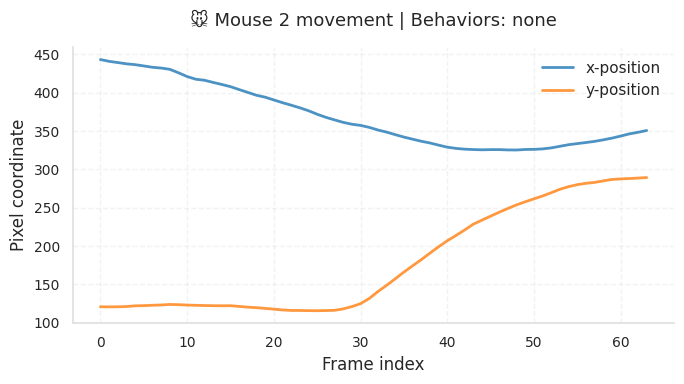

In [17]:
# 4-3: test one window → X [D,T] and y [num_actions] (with polished plot)

import os, pandas as pd, numpy as np, gzip, pickle, matplotlib.pyplot as plt, random, seaborn as sns

sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#E0E0E0",
    "grid.color": "#E0E0E0",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# --- load artifacts
win_idx = pd.read_parquet(f"{OUT}/window_index.parquet")
with gzip.open(f"{OUT}/label_map.pkl.gz", "rb") as f:
    label_map = pickle.load(f)

# --- choose random window
r = win_idx.sample(1, random_state=42).iloc[0]
vid, mouse, s, e, fp = r.video_id, str(r.mouse_id), int(r.start), int(r.stop), r.path
print(f"🎥 video: {vid} | 🐭 mouse: {mouse} | frames: {s}–{e}")

# --- load tracking slice
def read_any(fp):
    ext = os.path.splitext(fp)[1].lower()
    if ext == ".csv": return pd.read_csv(fp)
    if ext in (".parquet", ".pq"): return pd.read_parquet(fp)
    raise ValueError

df = read_any(fp)
lc = {c.lower(): c for c in df.columns}
vf = lc.get("video_frame") or lc.get("frame") or lc.get("frame_index")
mid = lc.get("mouse_id") or lc.get("mouse") or lc.get("id")

sl = df[(df[mid].astype(str) == mouse) & (df[vf].between(s, e-1, inclusive="both"))]
num_cols = [c for c in sl.columns if sl[c].dtype.kind in "fc"]
X = sl.groupby(sl[vf])[num_cols].mean().to_numpy(dtype=np.float32).T

# --- label vector
y = np.zeros(len(ACT2IDX), dtype=np.float32)
for (vv, ag, tg), events in label_map.items():
    if vv != str(vid) or ag != str(mouse):
        continue
    for (a, ss, ee) in events:
        if ee > s and ss < e and a in ACT2IDX:
            y[ACT2IDX[a]] = 1.0

pos_labels = [a for a, v in zip(ACTIONS, y) if v == 1.0]

print("X shape [features, frames]:", X.shape)
print("active behaviors:", pos_labels if pos_labels else "none")

# --- pretty visualization
if X.shape[0] >= 2:
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(X[0], label="x-position", color="#1f77b4", linewidth=2, alpha=0.8)
    ax.plot(X[1], label="y-position", color="#ff7f0e", linewidth=2, alpha=0.8)
    ax.set_title(f"🐭 Mouse {mouse} movement | Behaviors: {', '.join(pos_labels[:3]) or 'none'}", pad=15)
    ax.set_xlabel("Frame index")
    ax.set_ylabel("Pixel coordinate")
    ax.legend(frameon=False)
    ax.grid(True, linestyle="--", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()


🎥 video: 1264225733 | 🐭 agent: 1 → target: 2
window: 12576–12640 | event: attack [10703–14572]
X shape [features, frames]: (2, 64)
labels active in this window: ['attack']


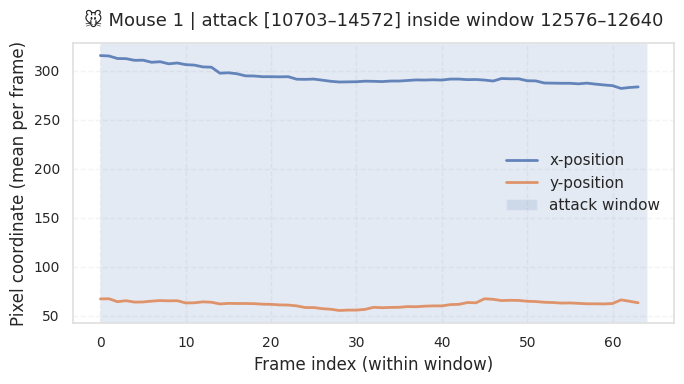

In [18]:
# 4-3 (positive): pick a window that actually has a labeled behavior and plot it

import os, pandas as pd, numpy as np, gzip, pickle, matplotlib.pyplot as plt

# load artifacts
win_idx = pd.read_parquet(f"{OUT}/window_index.parquet")
with gzip.open(f"{OUT}/label_map.pkl.gz","rb") as f:
    label_map = pickle.load(f)

# prefer to showcase one of these behaviors; fallback to any
PRIORITY = ["attack","chase","mount","sniff","sniffgenital","sniffface","approach","rear"]

# collect candidate (vid, agent_id, target_id, action, s, e)
cands = []
for (vid, ag, tg), events in label_map.items():
    for (a, s, e) in events:
        cands.append((vid, str(ag), str(tg), a, int(s), int(e)))

# rank: by priority first, then longer duration
prio_rank = {a:i for i,a in enumerate(PRIORITY)}
def score(t):
    vid, ag, tg, a, s, e = t
    pr = prio_rank.get(a, 999)
    return (pr, -(e - s))

cands.sort(key=score)

if not cands:
    raise RuntimeError("No labeled events found; check annotations.")

# find a window in win_idx that covers the mid-point of a top-ranked event
chosen = None
for (vid, ag, tg, a, s, e) in cands[:5000]:  # scan a reasonable prefix
    mid = (s + e) // 2
    # windows for this video + agent (mouse_id)
    sub = win_idx[(win_idx.video_id.astype(str) == str(vid)) & (win_idx.mouse_id.astype(str) == str(ag))]
    hit = sub[(sub.start <= mid) & (mid < sub.stop)]
    if len(hit):
        row = hit.iloc[0]
        chosen = (row, (vid, ag, tg, a, s, e))
        break

if chosen is None:
    raise RuntimeError("Couldn't match an event to a window. Try increasing scan limit or check index.")

row, meta = chosen
vid, ag, tg, action, s, e = meta
start, stop, fp = int(row.start), int(row.stop), row.path

print(f"🎥 video: {vid} | 🐭 agent: {ag} → target: {tg}")
print(f"window: {start}–{stop} | event: {action} [{s}–{e}]")

# read tracking (csv/parquet)
def read_any(fp):
    ext = os.path.splitext(fp)[1].lower()
    if ext == ".csv": return pd.read_csv(fp)
    if ext in (".parquet",".pq"): return pd.read_parquet(fp)
    raise ValueError

df = read_any(fp)
lc = {c.lower(): c for c in df.columns}
vf = lc.get("video_frame") or lc.get("frame") or lc.get("frame_index")
mid_col = lc.get("mouse_id") or lc.get("mouse") or lc.get("id")

# slice this agent + window
sl = df[(df[mid_col].astype(str) == str(ag)) & (df[vf].between(start, stop-1, inclusive="both"))]
num_cols = [c for c in sl.columns if sl[c].dtype.kind in "fc"]
X = sl.groupby(sl[vf])[num_cols].mean().to_numpy(dtype=np.float32).T  # [D, T]

# build multilabel y for info
y = np.zeros(len(ACT2IDX), dtype=np.float32)
for (vv, ag2, tg2), events in label_map.items():
    if vv != str(vid) or ag2 != str(ag):
        continue
    for (a2, s2, e2) in events:
        if e2 > start and s2 < stop and a2 in ACT2IDX:
            y[ACT2IDX[a2]] = 1.0
pos_labels = [a for a, v in zip(ACTIONS, y) if v == 1.0]

print("X shape [features, frames]:", X.shape)
print("labels active in this window:", pos_labels)

# --- pretty plot (x/y means) with event band highlighted
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,4))

if X.shape[0] >= 2:
    ax.plot(X[0], label="x-position", linewidth=2, alpha=0.85)
    ax.plot(X[1], label="y-position", linewidth=2, alpha=0.85)

# event band clipped to window coords
ev_a = max(s - start, 0)
ev_b = max(min(e - start, X.shape[1] if X.ndim == 2 else (stop-start)), 0)
if ev_b > ev_a:
    ax.axvspan(ev_a, ev_b, alpha=0.15, label=f"{action} window")

ax.set_title(f"🐭 Mouse {ag} | {action} [{s}–{e}] inside window {start}–{stop}", pad=12)
ax.set_xlabel("Frame index (within window)")
ax.set_ylabel("Pixel coordinate (mean per frame)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [19]:
# 4-4: save a small window index + actions list for quick experiments

import pandas as pd, json, os

ROOT = "/content/COMP433-MABe-BehaviorRecognition"
CONF = f"{ROOT}/configs"
OUT  = f"{ROOT}/outputs"

# load full index, then take a manageable slice for prototyping
win_idx = pd.read_parquet(f"{OUT}/window_index.parquet")
small = win_idx.sample(50000, random_state=1337) if len(win_idx) > 50000 else win_idx.copy()
small_path = f"{OUT}/window_index_small.parquet"
small.to_parquet(small_path, index=False)

# save actions list (one per line)
with open(f"{CONF}/actions_discovered.txt") as f:
    actions = [ln.strip() for ln in f if ln.strip()]
with open(f"{CONF}/actions_list.txt","w") as f:
    f.write("\n".join(actions))

print("✅ saved small index:", small.shape, "→", small_path)
print("✅ actions list saved →", f"{CONF}/actions_list.txt")


✅ saved small index: (50000, 5) → /content/COMP433-MABe-BehaviorRecognition/outputs/window_index_small.parquet
✅ actions list saved → /content/COMP433-MABe-BehaviorRecognition/configs/actions_list.txt


In [20]:
# 5-0 (safe): Dataset + DataLoader with robust empty-window handling

import os, json, gzip, pickle, pandas as pd, numpy as np, torch
from torch.utils.data import Dataset, DataLoader

ROOT = "/content/COMP433-MABe-BehaviorRecognition"
CONF = f"{ROOT}/configs"
OUT  = f"{ROOT}/outputs"

with open(f"{CONF}/constants.json") as f:
    C = json.load(f)
with open(f"{CONF}/actions_list.txt") as f:
    ACTIONS = [ln.strip() for ln in f if ln.strip()]
ACT2IDX = {a:i for i,a in enumerate(ACTIONS)}
NUM_CLASSES = len(ACTIONS)

win_idx = pd.read_parquet(f"{OUT}/window_index_small.parquet")
with gzip.open(f"{OUT}/label_map.pkl.gz","rb") as f:
    label_map = pickle.load(f)

WINDOW = int(C["WINDOW"])  # 64

def read_any(fp, cols=None):
    ext = os.path.splitext(fp)[1].lower()
    if ext == ".csv":
        return pd.read_csv(fp, usecols=cols)
    if ext in (".parquet",".pq"):
        try:
            import pyarrow  # noqa: F401
        except ImportError:
            import sys, subprocess
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyarrow"], check=False)
        return pd.read_parquet(fp, columns=cols)
    raise ValueError(f"unsupported file type: {ext}")

class MABeWindows(Dataset):
    """Returns (X[T,D], y[C], meta) for each window; robust to empty/odd rows."""
    def __init__(self, index_df, label_map, act2idx, window=64):
        self.df = index_df.reset_index(drop=True)
        self.label_map = label_map
        self.act2idx = act2idx
        self.window = int(window)

    def __len__(self): return len(self.df)

    def _safe_features(self, sl, vf):
        # choose 2 numeric columns (prefer x,y names if present)
        if sl.empty:
            return np.zeros((0, 2), dtype=np.float32)
        lower = {c.lower(): c for c in sl.columns}
        xy = []
        if "x" in lower: xy.append(lower["x"])
        if "y" in lower: xy.append(lower["y"])
        if len(xy) < 2:
            num_cols = [c for c in sl.columns if sl[c].dtype.kind in "fc"]
            if len(num_cols) >= 2:
                xy = num_cols[:2]
            elif len(num_cols) == 1:
                # duplicate the single numeric column
                xy = [num_cols[0], num_cols[0]]
            else:
                # no numeric columns -> return empty
                return np.zeros((0, 2), dtype=np.float32)
        g = sl.groupby(sl[vf])[xy].mean().to_numpy(dtype=np.float32)
        return g  # [T,2] (or [T,k] but we ensure 2 above)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        vid, mouse, s, e, fp = str(r.video_id), str(r.mouse_id), int(r.start), int(r.stop), r.path

        df = read_any(fp)
        lc = {c.lower(): c for c in df.columns}
        vf = lc.get("video_frame") or lc.get("frame") or lc.get("frame_index")
        mid = lc.get("mouse_id")   or lc.get("mouse") or lc.get("id")
        if vf is None or mid is None:
            # degenerate: return zeros
            X = np.zeros((self.window, 2), np.float32)
            y = np.zeros(len(self.act2idx), np.float32)
            return torch.from_numpy(X), torch.from_numpy(y), {"video_id":vid,"mouse_id":mouse,"start":s,"stop":e}

        sl = df[(df[mid].astype(str) == mouse) & (df[vf].between(s, e-1, inclusive="both"))]

        g = self._safe_features(sl, vf)  # [T,2] possibly T==0
        T = len(g)
        if T == 0:
            X = np.zeros((self.window, 2), np.float32)
        elif T < self.window:
            pad = np.repeat(g[-1:], self.window - T, axis=0)
            X = np.concatenate([g, pad], axis=0)
        else:
            X = g[:self.window]
        # labels
        y = np.zeros(len(self.act2idx), np.float32)
        for (vv, ag, tg), events in self.label_map.items():
            if vv != vid or ag != str(mouse):
                continue
            for (a, ss, ee) in events:
                if ee > s and ss < e and a in self.act2idx:
                    y[self.act2idx[a]] = 1.0

        return torch.from_numpy(X), torch.from_numpy(y), {"video_id":vid,"mouse_id":mouse,"start":s,"stop":e}

# Use num_workers=0 to avoid background-worker/environment issues.
dl = DataLoader(MABeWindows(win_idx.head(4096), label_map, ACT2IDX, window=WINDOW),
                batch_size=32, shuffle=True, num_workers=0, pin_memory=False)

Xb, yb, meta = next(iter(dl))
print("batch X:", tuple(Xb.shape), "  # [B,T,D]")
print("batch y:", tuple(yb.shape), "  # [B,C]")
print("first meta:", {k: v[0] for k,v in meta.items()})


batch X: (32, 64, 2)   # [B,T,D]
batch y: (32, 37)   # [B,C]
first meta: {'video_id': '495791948', 'mouse_id': '2', 'start': tensor(104224), 'stop': tensor(104288)}


In [21]:
# 5-1a: Minimal CNN + MLP baseline model

import torch
import torch.nn as nn
import torch.nn.functional as F

class TinyBehaviorNet(nn.Module):
    """Simple 1D CNN baseline for mouse-behavior classification."""
    def __init__(self, in_feats=2, hidden=64, num_classes=37):
        super().__init__()
        self.conv1 = nn.Conv1d(in_feats, hidden, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(0.3)
        self.fc1   = nn.Linear(hidden, hidden//2)
        self.fc2   = nn.Linear(hidden//2, num_classes)

    def forward(self, x):
        # x: [B, T, D] → [B, D, T] for Conv1d
        x = x.transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.adaptive_avg_pool1d(x, 1).squeeze(-1)   # [B, hidden]
        x = self.dropout(F.relu(self.fc1(x)))
        logits = self.fc2(x)                          # [B, num_classes]
        return logits

# --- instantiate model
num_classes = len(ACTIONS)
model = TinyBehaviorNet(in_feats=2, hidden=64, num_classes=num_classes).cuda()

# quick sanity pass
Xb = torch.randn(8, 64, 2).cuda()
logits = model(Xb)
print("✅ model output shape:", logits.shape)   # expected (8, 37)


✅ model output shape: torch.Size([8, 37])


In [ ]:
# 5-1b – Fast baseline training (optimized for progress report)
# Runs 4 epochs with tuned parameters for quick, stable results.

import torch, torch.nn as nn, torch.optim as optim
from tqdm.notebook import tqdm
import numpy as np, os, time

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- model: slightly larger hidden size for richer features
model = TinyBehaviorNet(in_feats=2, hidden=128, num_classes=len(ACTIONS)).to(device)

# --- optimizer & loss
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

# --- training configuration
EPOCHS = 4                                  # reduced from 10 → 4 for faster runs
save_path = f"{ROOT}/checkpoints/baseline_tiny.pt"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

loss_history = []

print(f"🚀 Training on {device.upper()}  |  Epochs: {EPOCHS}\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss, smooth_loss = 0.0, None
    pbar = tqdm(dl, desc=f"Epoch {epoch+1}/{EPOCHS}", ncols=100)

    for X, y, meta in pbar:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        smooth_loss = 0.9 * smooth_loss + 0.1 * loss.item() if smooth_loss else loss.item()
        pbar.set_postfix({"loss": f"{smooth_loss:.4f}"})

    avg_loss = running_loss / len(dl)
    loss_history.append(avg_loss)
    print(f"🧠 Epoch {epoch+1:2d}  |  avg loss = {avg_loss:.4f}")

torch.save(model.state_dict(), save_path)
print(f"\n✅ Model saved to: {save_path}")

# --- quick evaluation on one batch
model.eval()
with torch.no_grad():
    Xb, yb, meta = next(iter(dl))
    Xb, yb = Xb.to(device), yb.to(device)
    preds = torch.sigmoid(model(Xb))
    sample_preds = preds[0].cpu().numpy()
    top_actions = [a for a, p in sorted(zip(ACTIONS, sample_preds),
                                       key=lambda x: x[1], reverse=True)[:5]]
    print("\n🔍 Sample predicted top behaviors:", ", ".join(top_actions))

# --- final summary
print("\n📉 Loss per epoch:", [f"{l:.4f}" for l in loss_history])


In [26]:
%cd /content/COMP433-MABe-BehaviorRecognition
!git config --global user.name "Tala Tak"
!git config --global user.email "your_email@example.com"
from getpass import getpass
token = getpass('Enter your GitHub token: ')
!git remote set-url origin https://{token}@github.com/talatak/COMP433-MABe-BehaviorRecognition.git


/content/COMP433-MABe-BehaviorRecognition
Enter your GitHub token: ··········


In [29]:
!git push -u origin colab-setup


Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (10/10), 1.40 KiB | 1.40 MiB/s, done.
Total 10 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 1 local object.
remote: 
remote: Create a pull request for 'colab-setup' on GitHub by visiting:
remote:      https://github.com/talatak/COMP433-MABe-BehaviorRecognition/pull/new/colab-setup
remote: 
To https://github.com/talatak/COMP433-MABe-BehaviorRecognition.git
 * [new branch]      colab-setup -> colab-setup
Branch 'colab-setup' set up to track remote branch 'colab-setup' from 'origin'.


In [31]:
ls -lh notebooks/


total 0
